# Validation to datasets

In [1]:
import rioxarray as rxr
from rasterio.enums import Resampling
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

base = Path("/home/georg/data/LEON_P5_BII")

## LUI map to LAMASUS LUM map

In [2]:
# --- load Denmark
lum = rxr.open_rasterio("/home/georg/data/LEON_P5_BII/Validation/lum_dnk_2018_3035.tif")
lui = rxr.open_rasterio("/home/georg/data/LEON_P5_BII/BII_LU_layer/Land_use_map/v1/lu_intensity_dnk_2018_v1.tif")

# # --- load Netherlands
# lui = rxr.open_rasterio(base / "BII_LU_layer/Land_use_map/v1/lu_intensity_nld_2018_v1.tif")
# lum = rxr.open_rasterio(base / "Validation/lum_nld_2018_3035.tif")


# --- align LUI → LUM grid
lui_r = lui.rio.reproject_match(lum, resampling=Resampling.nearest)

lui_arr = lui_r.squeeze().values
lum_arr = lum.squeeze().values

In [3]:
OK = {
    230:[25], 231:[25], 232:[25],
    220:[2],  221:[3],  222:[3],
    210:[2],  211:[3],  212:[3],
    30:[4],   31:[4],   32:[5],
    70:[11],  71:[10],  72:[10],
    60:[18],  61:[17],  62:[16],
    10:[29],  11:[28],  12:[27],
}
valid_lui_codes = set(OK.keys())

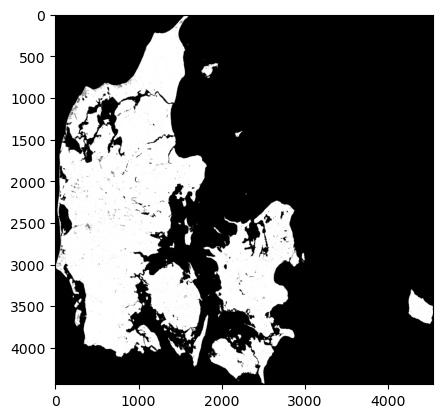

In [4]:
INVALID_LUI = [0, 255, 240, 241, 242]

valid = np.isin(lui_arr, list(valid_lui_codes))

plt.imshow(valid, cmap="gray")

In [5]:
match = np.zeros_like(lui_arr, dtype=bool)

for k, vals in OK.items():
    match |= ((lui_arr == k) & np.isin(lum_arr, vals))

overall_acc = match[valid].sum() / valid.sum()

print("NLD agreement:", f"{overall_acc:.2%}")

NLD agreement: 5.24%


In [6]:
print("\nConfusion counts (LUI_class → LUM_value : count):")
for k, vals in OK.items():
    mask = (lui_arr == k) & valid
    unique, counts = np.unique(lum_arr[mask], return_counts=True)
    print(k, dict(zip(unique, counts)))


Confusion counts (LUI_class → LUM_value : count):
230 {2: 565, 3: 3019, 4: 2018, 5: 14, 7: 3525, 8: 598, 10: 31, 11: 1, 12: 13, 13: 3, 15: 355, 16: 442, 17: 69, 18: 87, 19: 928, 20: 1837, 21: 1515, 22: 354, 25: 174, 26: 640, 27: 7, 28: 21, 29: 485, 30: 74, 31: 46, 32: 2798, 33: 2, 255: 64}
231 {2: 114, 3: 800, 4: 425, 5: 3, 7: 283, 8: 46, 15: 15, 16: 34, 17: 1, 18: 5, 19: 44, 20: 138, 21: 148, 22: 33, 25: 5, 26: 60, 29: 53, 30: 8, 31: 7, 32: 572, 255: 6}
232 {2: 28, 3: 119, 4: 23, 7: 16, 15: 1, 16: 1, 19: 1, 20: 14, 26: 4, 29: 3, 32: 72, 255: 1}
220 {2: 2714, 3: 13990, 4: 8416, 5: 82, 7: 14684, 8: 2072, 10: 71, 11: 5, 12: 28, 13: 5, 15: 1380, 16: 1468, 17: 260, 18: 389, 19: 3977, 20: 6953, 21: 5211, 22: 1623, 25: 332, 26: 1433, 27: 33, 28: 76, 29: 1421, 30: 242, 31: 56, 32: 6219, 33: 9, 255: 254}
221 {2: 595, 3: 3614, 4: 1780, 5: 3, 7: 1008, 8: 187, 9: 1, 10: 4, 11: 2, 13: 1, 15: 43, 16: 126, 17: 3, 18: 27, 19: 195, 20: 522, 21: 425, 22: 118, 25: 23, 26: 168, 27: 2, 28: 8, 29: 140, 30

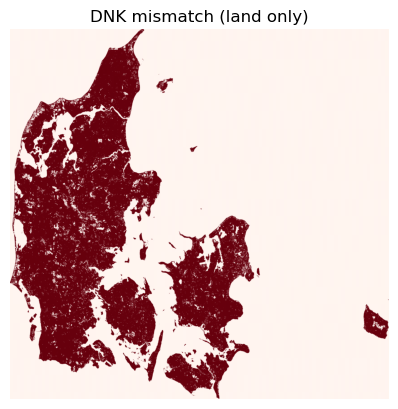

In [7]:
mismatch = (valid & (~match)).astype("uint8")

# add band dimension
mismatch3d = mismatch[np.newaxis, :, :]

# write raster
mismatch_da = lum.copy(data=mismatch3d)
mismatch_da.rio.to_raster("DNK_LUI_LUM_mismatch_landonly.tif")

# quick visualization
plt.imshow(mismatch, cmap="Reds")
plt.title("DNK mismatch (land only)")
plt.axis("off")
plt.show()

## Simple sub-class category

In [8]:
LUM_GROUP = {
    25:"Grassland",
    2:"Forest-light",
    3:"Forest-med",
    4:"Plantation-min",
    5:"Plantation-int",
    11:"Crop-light",
    10:"Crop-min",
    12:"Crop-int",
    18:"Pasture-min",
    17:"Pasture-light",
    16:"Pasture-int",
    29:"Urban-min",
    28:"Urban-light",
    27:"Urban-int",
}


In [9]:
lum_simple = np.full_like(lum_arr, fill_value=-1)   # -1 = Other

for lum_val, name in LUM_GROUP.items():
    lum_simple[lum_arr == lum_val] = lum_val

In [10]:
LUI_GROUP = {
    230:"SV-young",
    231:"SV-young",
    232:"SV-young",
    220:"SV-intermed-min",
    221:"SV-intermed-light",
    222:"SV-intermed-int",
    210:"SV-mature-min",
    211:"SV-mature-light",
    212:"SV-mature-int",
    30:"Plantation-min",
    31:"Plantation-light",
    32:"Plantation-int",
    70:"Cropland-min",
    71:"Cropland-light",
    72:"Cropland-int",
    60:"Pasture-min",
    61:"Pasture-light",
    62:"Pasture-int",
    10:"Urban-min",
    11:"Urban-light",
    12:"Urban-int"
}

In [ ]:
# Map LUI and LUM to their groups, using "Other" for unmapped values

lui_groups = np.vectorize(LUI_GROUP.get)(lui_arr, "Other")
lum_groups = np.vectorize(LUM_GROUP.get)(lum_simple, "Other")

unique_lui = sorted(set(lui_groups.flatten()) - {"Other"})
unique_lum = sorted(set(lum_groups.flatten()) - {"Other"})

conf = np.zeros((len(unique_lui), len(unique_lum)), dtype=int)

for i, lg in enumerate(unique_lui):
    for j, mg in enumerate(unique_lum):
        conf[i,j] = np.sum((lui_groups == lg) & (lum_groups == mg))


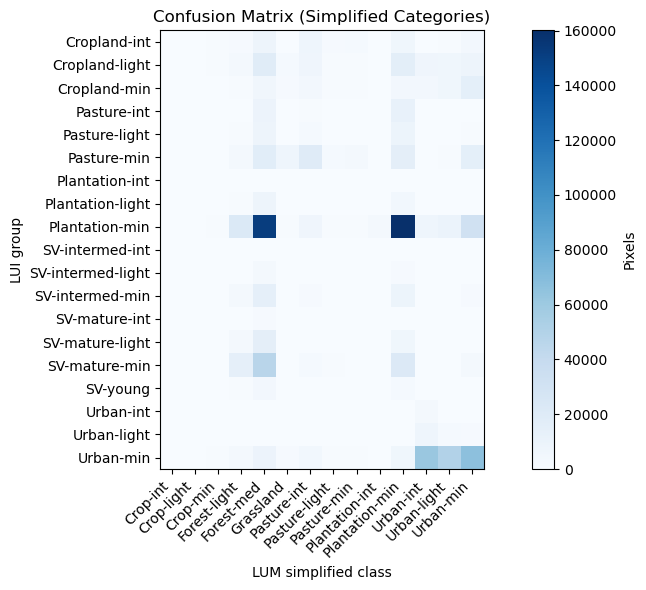

In [12]:
plt.figure(figsize=(10,6))
plt.imshow(conf, cmap="Blues")
plt.colorbar(label="Pixels")
plt.xticks(range(len(unique_lum)), unique_lum, rotation=45, ha='right')
plt.yticks(range(len(unique_lui)), unique_lui)
plt.xlabel("LUM simplified class")
plt.ylabel("LUI group")
plt.title("Confusion Matrix (Simplified Categories)")
plt.tight_layout()
plt.show()

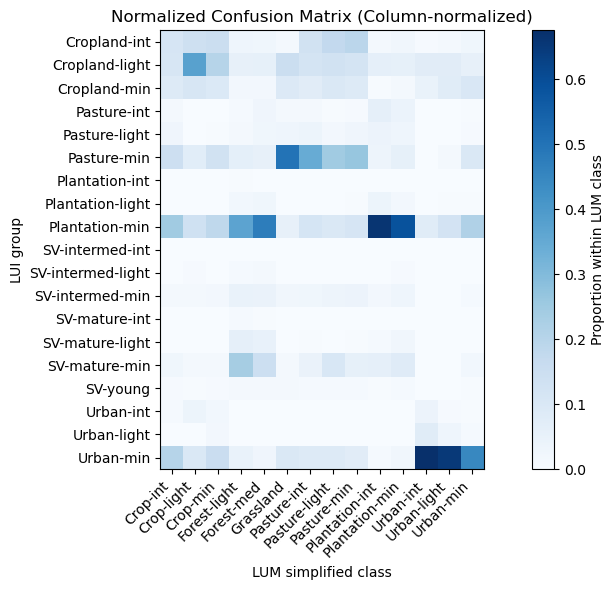

In [13]:
conf_norm = conf / conf.sum(axis=0, keepdims=True)

plt.figure(figsize=(10,6))
plt.imshow(conf_norm, cmap="Blues")
plt.colorbar(label="Proportion within LUM class")
plt.xticks(range(len(unique_lum)), unique_lum, rotation=45, ha='right')
plt.yticks(range(len(unique_lui)), unique_lui)
plt.xlabel("LUM simplified class")
plt.ylabel("LUI group")
plt.title("Normalized Confusion Matrix (Column-normalized)")
plt.tight_layout()
plt.show()

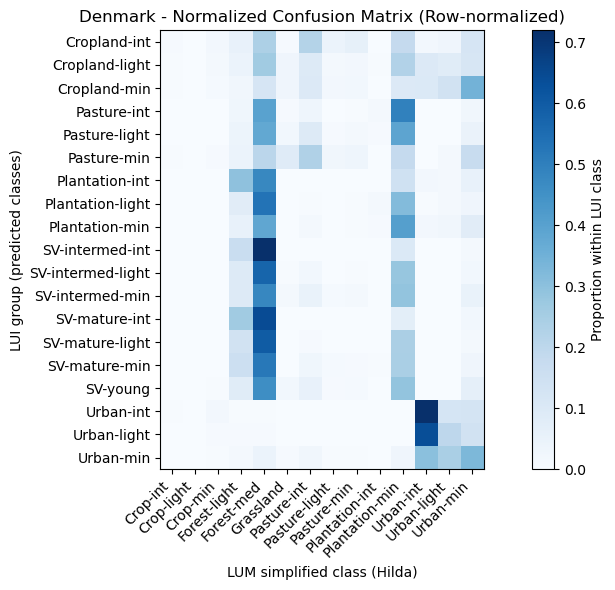

In [15]:
conf_norm = conf / conf.sum(axis=1, keepdims=True)   # row-normalised

plt.figure(figsize=(10,6))
plt.imshow(conf_norm, cmap="Blues")
plt.colorbar(label="Proportion within LUI class")  # optional: reflect row-normalised meaning
plt.xticks(range(len(unique_lum)), unique_lum, rotation=45, ha='right')
plt.yticks(range(len(unique_lui)), unique_lui)
plt.xlabel("LUM simplified class (Hilda)")
plt.ylabel("LUI group (predicted classes)")
plt.title("Denmark - Normalized Confusion Matrix (Row-normalized)")
plt.tight_layout()
plt.show()

## LUI to Hilda LU

In [15]:
# --- load Denmark
lui_dnk = rxr.open_rasterio("/home/georg/data/LEON_P5_BII/BII_LU_layer/Land_use_map/v1/lu_intensity_dnk_2018_v1.tif")
lu_hilda_dnk = rxr.open_rasterio(base / "Validation/lu_hilda_dnk_2018_3035.tif") 

# --- load Netherlands
lui_nld = rxr.open_rasterio(base / "BII_LU_layer/Land_use_map/v1/lu_intensity_nld_2018_v1.tif")
lu_hilda_nld = rxr.open_rasterio(base / "Validation/lu_hilda_nld_2018_3035.tif") 


# --- align LUI → LU Hilda grid
lui_dnk_r = lui_dnk.rio.reproject_match(lu_hilda_dnk, resampling=Resampling.nearest)
lui_nld_r = lui_nld.rio.reproject_match(lu_hilda_nld, resampling=Resampling.nearest)


lui_own_dnk_arr = lui_dnk_r.squeeze().values
lu_hilda_dnk_arr = lu_hilda_dnk.squeeze().values

lui_own_nld_arr = lui_nld_r.squeeze().values
lu_hilda_nld_arr = lu_hilda_nld.squeeze().values

In [16]:
LU_hilda_GROUP = {
    1:"Primary vegetation - minimal",
    2:"Primary vegetation",
    3:"Secondary vegetation",
    4:"Cropland",
    5:"Urban",
    6:"Pasture",
    7:"Plantation/Agroforestry",
}

In [17]:
LUI_GROUP = {
    230:"SV-young",
    231:"SV-young",
    232:"SV-young",
    220:"SV-intermed-min",
    221:"SV-intermed-light",
    222:"SV-intermed-int",
    210:"SV-mature-min",
    211:"SV-mature-light",
    212:"SV-mature-int",
    30:"Plantation-min",
    31:"Plantation-light",
    32:"Plantation-int",
    70:"Cropland-min",
    71:"Cropland-light",
    72:"Cropland-int",
    60:"Pasture-min",
    61:"Pasture-light",
    62:"Pasture-int",
    10:"Urban-min",
    11:"Urban-light",
    12:"Urban-int"
}

In [18]:
import numpy as np
from sklearn.metrics import confusion_matrix

# ---------- 1) Define mappings ----------
HILDA_TO_COARSE = {
    3: "SV",
    7: "Plantation",
    5: "Urban",
    4: "Cropland",
    6: "Pasture",
}

LUI_TO_COARSE = {
    # SV
    230:"SV", 231:"SV", 232:"SV",
    220:"SV", 221:"SV", 222:"SV",
    210:"SV", 211:"SV", 212:"SV",

    # Plantation
    30:"Plantation", 31:"Plantation", 32:"Plantation",

    # Cropland
    70:"Cropland", 71:"Cropland", 72:"Cropland",

    # Pasture
    60:"Pasture", 61:"Pasture", 62:"Pasture",

    # Urban
    10:"Urban", 11:"Urban", 12:"Urban",
}

COARSE_LABELS = ["SV", "Plantation", "Urban", "Cropland", "Pasture"]


def arrays_to_coarse_pairs(lui_arr, hilda_arr):
    lui_f = lui_arr.ravel()
    hil_f = hilda_arr.ravel()

    # Valid pixels = both are in dictionary keys
    mask = np.isin(lui_f, list(LUI_TO_COARSE.keys())) & \
           np.isin(hil_f, list(HILDA_TO_COARSE.keys()))

    lui_coarse = np.array([LUI_TO_COARSE[int(v)] for v in lui_f[mask]])
    hilda_coarse = np.array([HILDA_TO_COARSE[int(v)] for v in hil_f[mask]])

    return lui_coarse, hilda_coarse


def compute_confusions(lui_arr, hilda_arr, labels=COARSE_LABELS):
    """
    Confusion matrix where:
        rows   = LUI (your prediction)
        cols   = Hilda (reference)
    """
    y_lui, y_hilda = arrays_to_coarse_pairs(lui_arr, hilda_arr)

    # IMPORTANT: predicted first, reference second
    cm = confusion_matrix(y_lui, y_hilda, labels=labels)

    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    return cm, cm_norm, labels


def pretty_print_cm(cm, labels, title="Confusion matrix"):
    print(f"\n{title} (rows = LUI, cols = Hilda/reference)")
    header = ["{:>12}".format("")] + ["{:>12}".format(lbl) for lbl in labels]
    print("".join(header))
    for i, row in enumerate(cm):
        row_str = ["{:>12}".format(labels[i])] + ["{:>12}".format(x) for x in row]
        print("".join(row_str))


# ---------- 2) Denmark ----------
cm_d, cmn_d, labels = compute_confusions(lui_own_dnk_arr, lu_hilda_dnk_arr)
pretty_print_cm(cm_d, labels, "Denmark - counts")
pretty_print_cm(np.round(cmn_d, 3), labels, "Denmark - normalized")

# ---------- 3) Netherlands ----------
cm_n, cmn_n, labels = compute_confusions(lui_own_nld_arr, lu_hilda_nld_arr)
pretty_print_cm(cm_n, labels, "Netherlands - counts")
pretty_print_cm(np.round(cmn_n, 3), labels, "Netherlands - normalized")



Denmark - counts (rows = LUI, cols = Hilda/reference)
                      SV  Plantation       Urban    Cropland     Pasture
          SV        8038          62        1798       14014        1108
  Plantation       21915         176        4560       29342        2311
       Urban        5981         180       18516       21128        3260
    Cropland       22670        1471       17797      210304       10246
     Pasture        9921         312        1908       38618       10906

Denmark - normalized (rows = LUI, cols = Hilda/reference)
                      SV  Plantation       Urban    Cropland     Pasture
          SV       0.321       0.002       0.072        0.56       0.044
  Plantation       0.376       0.003       0.078       0.503        0.04
       Urban       0.122       0.004       0.377       0.431       0.066
    Cropland       0.086       0.006       0.068       0.801       0.039
     Pasture       0.161       0.005       0.031       0.626       0.177

Netherlan

In [19]:
import numpy as np

def confusion_stats(cm, labels):
    """
    Given confusion matrix (rows=LUI predicted, cols=Hilda reference),
    return accuracy stats in a dictionary.
    """

    # Total correct
    diag = np.diag(cm)
    total = cm.sum()

    # Overall accuracy
    oa = diag.sum() / total if total > 0 else np.nan

    # Per-class recall (Producer's accuracy): TP / (TP + FN)
    recall = diag / cm.sum(axis=1)

    # Per-class precision (User's accuracy): TP / (TP + FP)
    precision = diag / cm.sum(axis=0)

    # F1 score
    f1 = 2 * (precision * recall) / (precision + recall)

    # Balanced accuracy (mean recall)
    bal_acc = np.nanmean(recall)

    # Cohen’s kappa
    row_marg = cm.sum(axis=1)
    col_marg = cm.sum(axis=0)
    expected = (row_marg * col_marg).sum() / (total * total)
    kappa = (oa - expected) / (1 - expected) if expected < 1 else np.nan

    return {
        "Overall accuracy": oa,
        "Balanced accuracy": bal_acc,
        "Kappa": kappa,
        "Per-class precision": dict(zip(labels, precision)),
        "Per-class recall": dict(zip(labels, recall)),
        "Per-class F1": dict(zip(labels, f1)),
    }

# ---- Denmark ----
stats_dnk = confusion_stats(cm_d, labels)
print("\nDenmark stats:")
for k, v in stats_dnk.items():
    print(k, ":", v)

# ---- Netherlands ----
stats_nld = confusion_stats(cm_n, labels)
print("\nNetherlands stats:")
for k, v in stats_nld.items():
    print(k, ":", v)


Denmark stats:
Overall accuracy : 0.5430825641452484
Balanced accuracy : 0.3359424309341844
Kappa : 0.209131622072766
Per-class precision : {'SV': 0.11730025538124772, 'Plantation': 0.07996365288505225, 'Urban': 0.4153525202449584, 'Cropland': 0.6710273574851789, 'Pasture': 0.39186518630304334}
Per-class recall : {'SV': 0.32126298960831334, 'Plantation': 0.0030186608122941823, 'Urban': 0.3773769489452767, 'Cropland': 0.8011947212824967, 'Pasture': 0.17685883402254116}
Per-class F1 : {'SV': 0.17185311881981935, 'Plantation': 0.0058177010164449225, 'Urban': 0.39545512793131427, 'Cropland': 0.7303566281294821, 'Pasture': 0.24372038973808882}

Netherlands stats:
Overall accuracy : 0.4298861651184513
Balanced accuracy : 0.3601143742457216
Kappa : 0.21716682940348295
Per-class precision : {'SV': 0.12451669408070408, 'Plantation': 0.0806979280261723, 'Urban': 0.5797624861835848, 'Cropland': 0.5009436521357705, 'Pasture': 0.3039965453355064}
Per-class recall : {'SV': 0.41211821266968324, 'Pla

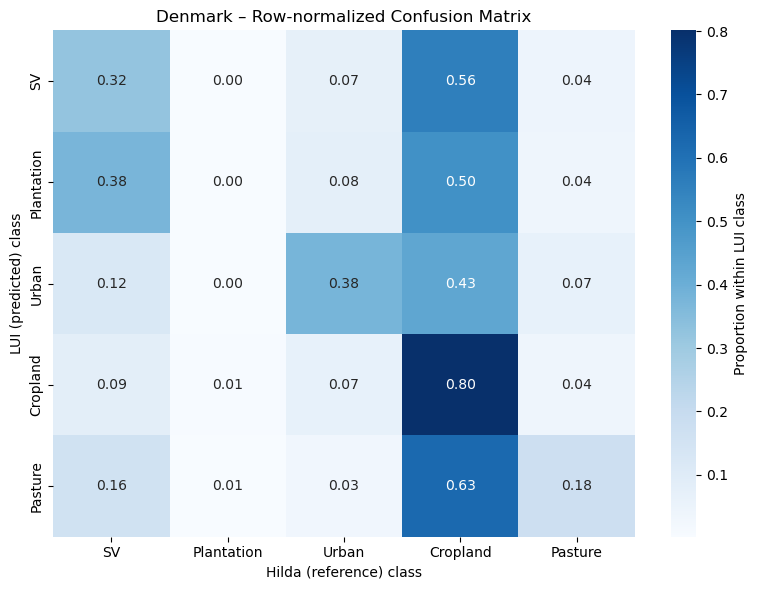

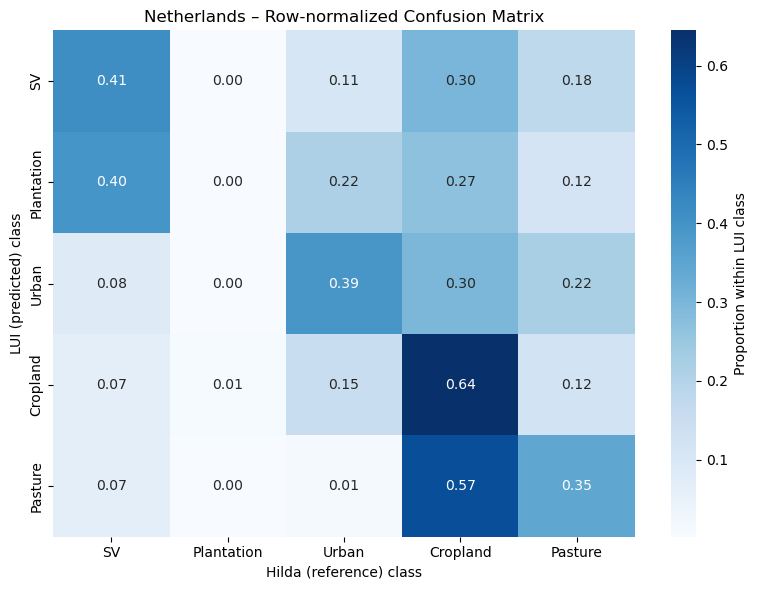

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def normalize_rows(cm):
    row_sums = cm.sum(axis=1, keepdims=True)
    with np.errstate(divide='ignore', invalid='ignore'):
        cm_norm = cm / row_sums
    return cm_norm

def plot_row_norm(cm, labels, title):
    cm_norm = normalize_rows(cm)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=labels, yticklabels=labels,
                cbar_kws={'label': 'Proportion within LUI class'})
    plt.xlabel("Hilda (reference) class")
    plt.ylabel("LUI (predicted) class")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# ---- Denmark ----
plot_row_norm(cm_d, labels,
              title="Denmark – Row-normalized Confusion Matrix")

# ---- Netherlands ----
plot_row_norm(cm_n, labels,
              title="Netherlands – Row-normalized Confusion Matrix")

# Compare BII

In [21]:
#--- Load BII layers ---
bii_dnk_gess_18 = rxr.open_rasterio(base / "Validation/BII/BII_dnk_gessert_2018.tif").squeeze()
bii_nld_gess_18 = rxr.open_rasterio(base / "Validation/BII/BII_nld_gessert_2018.tif").squeeze()

bii_glob_nguy_18 = rxr.open_rasterio(base / "Validation/BII/BII_global_nguyen_2018_v2.tif").squeeze()

bii_euro_lama = rxr.open_rasterio(base / "Validation/BII/BII_europe_lamasus.tif")
bii_euro_lama_18 = bii_euro_lama.sel(band=21)

bii_dnk_own_18 = rxr.open_rasterio(base / "BII_LU_layer/BII layers/v1/bii_world_DK_18.tif").squeeze()
bii_nld_own_18 = rxr.open_rasterio(base / "BII_LU_layer/BII layers/v1/bii_world_NL_18.tif").squeeze()


# --- Print CRS & shape (super simple) ---
print("DK gess 2018:", bii_dnk_gess_18.rio.crs, bii_dnk_gess_18.shape)
print("NL gess 2018:", bii_nld_gess_18.rio.crs, bii_nld_gess_18.shape)
print("Global Nguyen 2018:", bii_glob_nguy_18.rio.crs, bii_glob_nguy_18.shape)
print("Europe Lamasus:", bii_euro_lama_18.rio.crs, bii_euro_lama_18.shape)
print("DK own 2018:", bii_dnk_own_18.rio.crs, bii_dnk_own_18.shape)
print("NL own 2018:", bii_nld_own_18.rio.crs, bii_nld_own_18.shape)


DK gess 2018: EPSG:4326 (3611, 7923)
NL gess 2018: EPSG:4326 (3170, 4305)
Global Nguyen 2018: EPSG:4326 (7157, 18000)
Europe Lamasus: EPSG:3035 (4525, 5634)
DK own 2018: EPSG:3035 (353, 450)
NL own 2018: EPSG:3035 (313, 276)


In [22]:
print(bii_euro_lama.attrs)

{'AREA_OR_POINT': 'Area', 'STATISTICS_MAXIMUM': 1, 'STATISTICS_MEAN': -9999, 'STATISTICS_MINIMUM': 0.51617860794067, 'STATISTICS_STDDEV': -9999, '_FillValue': nan, 'scale_factor': 1.0, 'add_offset': 0.0, 'long_name': ('Species richness__2000', 'Species richness__2010', 'Species richness__2018', 'Total abundance__2000', 'Total abundance__2010', 'Total abundance__2018', 'Geometric mean abundance__2000', 'Geometric mean abundance__2010', 'Geometric mean abundance__2018', 'Sorensen__2000', 'Sorensen__2010', 'Sorensen__2018', 'Bray-Curtis__2000', 'Bray-Curtis__2010', 'Bray-Curtis__2018', 'Canberra__2000', 'Canberra__2010', 'Canberra__2018', 'BII__2000', 'BII__2010', 'BII__2018')}


In [23]:
#--- Reproject & Clip ---#


def align_to_country(src, country_ref):
    """
    Reproject + align + mask using reference raster exactly.
    - Same CRS
    - Same extent
    - Same resolution
    - Masked using country_ref (NaN outside country)
    """
    # 1. Reproject & match extent/resolution
    aligned = src.rio.reproject_match(country_ref)
    
    # 2. Mask: keep only where reference has data
    aligned = aligned.where(~np.isnan(country_ref))
    
    return aligned

#_______Denmark_______#

ref_dk = bii_dnk_own_18  # 353 × 450, EPSG:3035

bii_gess_18_dk = align_to_country(bii_dnk_gess_18, ref_dk)
bii_nguy_18_dk = align_to_country(bii_glob_nguy_18, ref_dk)
bii_lama_18_dk = align_to_country(bii_euro_lama_18, ref_dk)

#_______Nerherlands_______#

ref_nl = bii_nld_own_18  # 313 × 276, EPSG:3035

bii_gess_18_nl   = align_to_country(bii_nld_gess_18, ref_nl)
bii_nguy_18_nl = align_to_country(bii_glob_nguy_18, ref_nl)
bii_lama_18_nl = align_to_country(bii_euro_lama_18, ref_nl)


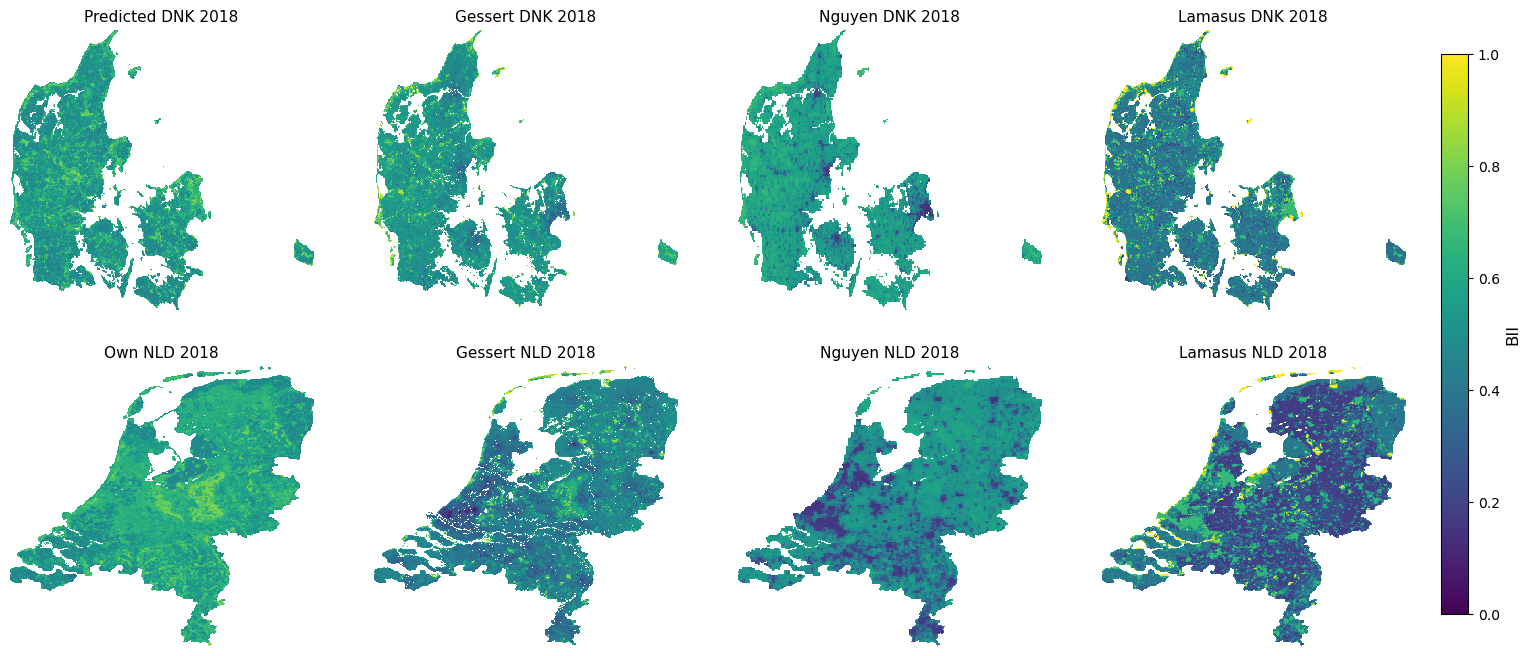

In [41]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Your 8 maps
plots = [
    ("Predicted DNK 2018", bii_dnk_own_18),
    ("Gessert DNK 2018", bii_gess_18_dk),
    ("Nguyen DNK 2018", bii_nguy_18_dk),
    ("Lamasus DNK 2018", bii_lama_18_dk),
    ("Own NLD 2018", bii_nld_own_18),
    ("Gessert NLD 2018", bii_gess_18_nl),
    ("Nguyen NLD 2018", bii_nguy_18_nl),
    ("Lamasus NLD 2018", bii_lama_18_nl),
]

# Clean metadata to avoid long labels
def clean(da):
    da = da.copy()
    for k in ["long_name", "description", "units"]:
        da.attrs.pop(k, None)
    return da

plots = [(title, clean(da)) for title, da in plots]

# Create grid (2 rows x 4 columns)
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()

# Common settings
vmin, vmax = 0, 1
cmap = "viridis"

# Plot the rasters
for ax, (title, da) in zip(axes, plots):
    im = da.plot.imshow(ax=ax, cmap=cmap, vmin=vmin, vmax=vmax, add_colorbar=False)
    ax.set_title(title, fontsize=11)
    ax.set_axis_off()

# --- Add colorbar in its own axis ---
cax = fig.add_axes([0.92, 0.15, 0.015, 0.7])  # [left, bottom, width, height]

cb = plt.colorbar(im, cax=cax)
cb.set_label("BII", fontsize=12)

plt.subplots_adjust(right=0.9)  # make room for the colorbar
plt.show()

### Stats

In [25]:
import numpy as np
import pandas as pd

def compare_maps(ref, other):
    """
    Returns RMSE, MAE, and Pearson correlation between two aligned rasters.
    Ignores NaNs automatically.
    """
    a = ref.values.flatten()
    b = other.values.flatten()

    mask = ~np.isnan(a) & ~np.isnan(b)

    a = a[mask]
    b = b[mask]

    rmse = np.sqrt(np.mean((a - b)**2))
    mae  = np.mean(np.abs(a - b))
    corr = np.corrcoef(a, b)[0, 1]

    return pd.Series({"RMSE": rmse, "MAE": mae, "r": corr})


In [26]:
print("DK — Gessert:", compare_maps(bii_dnk_own_18, bii_gess_18_dk))
print("DK — Nguyen:", compare_maps(bii_dnk_own_18, bii_nguy_18_dk))
print("DK — Lamasus:", compare_maps(bii_dnk_own_18, bii_lama_18_dk))

print("NL — Gessert:", compare_maps(bii_nld_own_18, bii_gess_18_nl))
print("NL — Nguyen:", compare_maps(bii_nld_own_18, bii_nguy_18_nl))
print("NL — Lamasus:", compare_maps(bii_nld_own_18, bii_lama_18_nl))

DK — Gessert: RMSE    0.100992
MAE     0.074335
r       0.389607
dtype: float64
DK — Nguyen: RMSE    0.127906
MAE     0.097920
r      -0.050098
dtype: float64
DK — Lamasus: RMSE    0.178263
MAE     0.137665
r       0.290161
dtype: float64
NL — Gessert: RMSE    0.187029
MAE     0.158711
r       0.208515
dtype: float64
NL — Nguyen: RMSE    0.204220
MAE     0.157375
r      -0.093239
dtype: float64
NL — Lamasus: RMSE    0.297476
MAE     0.253519
r       0.057762
dtype: float64


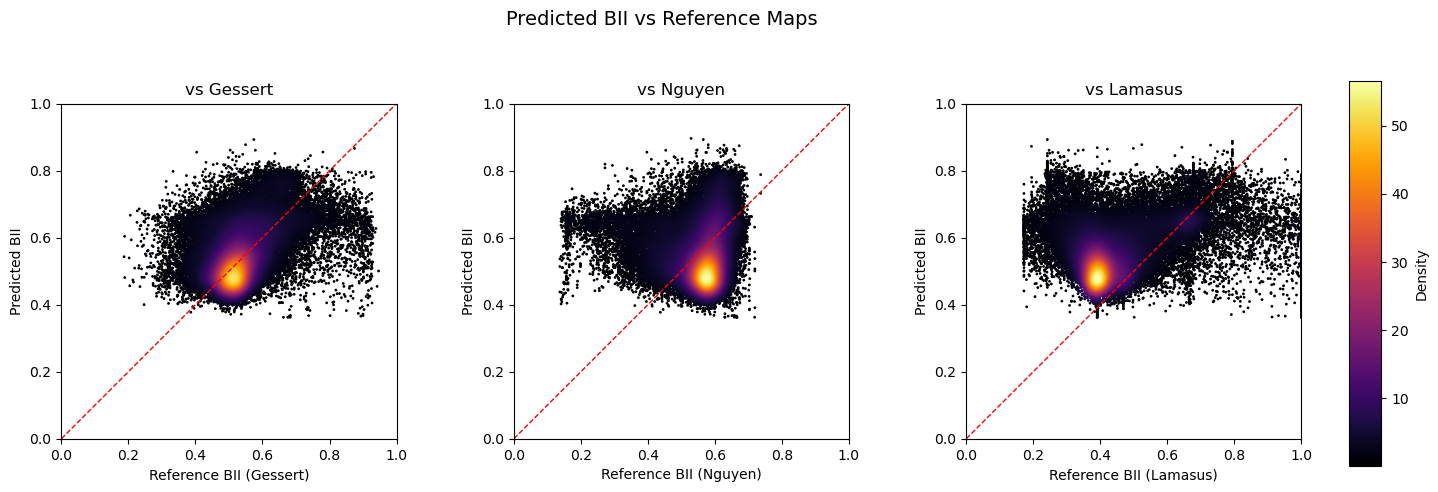

In [40]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
from matplotlib.colors import Normalize

def density_compare_trio(predicted, references, ref_labels):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))

    plot_data = []
    for ref in references:
        a = ref.values.flatten()
        b = predicted.values.flatten()
        mask = ~np.isnan(a) & ~np.isnan(b)
        x, y = a[mask], b[mask]
        xy = np.vstack([x, y])
        density = gaussian_kde(xy)(xy)
        plot_data.append((x, y, density))

    all_dens = np.concatenate([d[2] for d in plot_data])
    norm = Normalize(vmin=all_dens.min(), vmax=all_dens.max())

    for ax, (x, y, density), label in zip(axes, plot_data, ref_labels):
        idx = density.argsort()
        x, y, density = x[idx], y[idx], density[idx]

        sc = ax.scatter(x, y, c=density, s=1, cmap="inferno", norm=norm)
        ax.plot([0, 1], [0, 1], "r--", lw=1)
        ax.set_xlabel(f"Reference BII ({label})")
        ax.set_ylabel("Predicted BII")
        ax.set_title(f"vs {label}")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_aspect("equal")

    # # Manual colorbar axis at the bottom
    # cbar_ax = fig.add_axes([0.25, 0.02, 0.5, 0.03])  # [left, bottom, width, height]
    # fig.colorbar(sc, cax=cbar_ax, orientation="horizontal", label="Density")

    # fig.suptitle("Predicted BII vs Reference Maps", fontsize=14)
    # fig.subplots_adjust(bottom=0.15, top=0.9, wspace=0.35)
    # plt.show()

    # colorbar on the right
    cbar_ax = fig.add_axes([0.93, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
    fig.colorbar(sc, cax=cbar_ax, orientation="vertical", label="Density")

    fig.suptitle("Predicted BII vs Reference Maps", fontsize=14)
    fig.subplots_adjust(right=0.9, top=0.9, wspace=0.35)
    plt.show()

density_compare_trio(
    bii_dnk_own_18,
    [bii_gess_18_dk, bii_nguy_18_dk, bii_lama_18_dk],
    ["Gessert", "Nguyen", "Lamasus"]
)

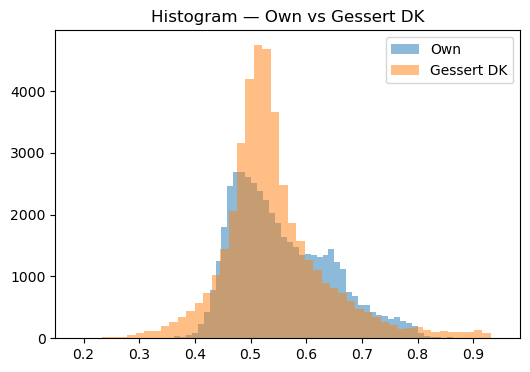

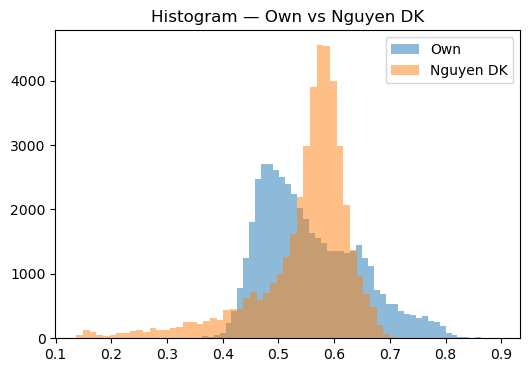

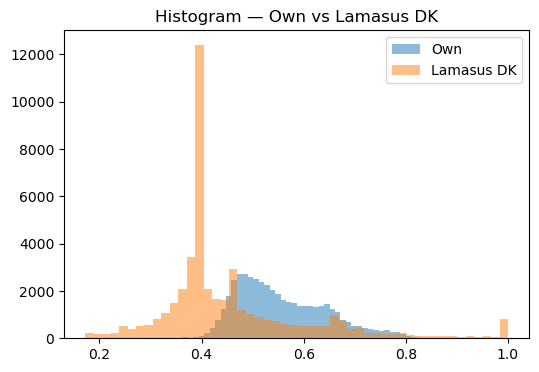

In [28]:
def hist_compare(ref, other, title):
    plt.figure(figsize=(6,4))
    plt.hist(ref.values.flatten(), bins=50, alpha=0.5, label="Own")
    plt.hist(other.values.flatten(), bins=50, alpha=0.5, label=title)
    plt.legend()
    plt.title(f"Histogram — Own vs {title}")
    plt.show()

    
hist_compare(bii_dnk_own_18, bii_gess_18_dk, "Gessert DK")
hist_compare(bii_dnk_own_18, bii_nguy_18_dk, "Nguyen DK")
hist_compare(bii_dnk_own_18, bii_lama_18_dk, "Lamasus DK")


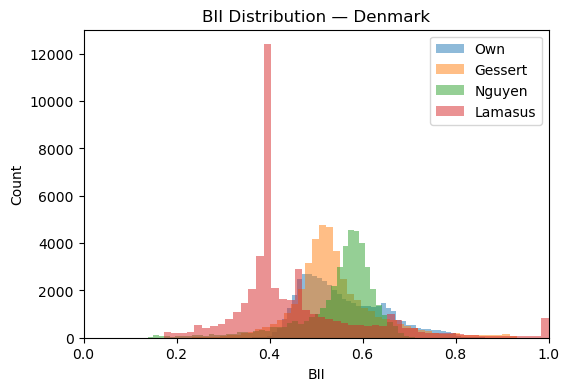

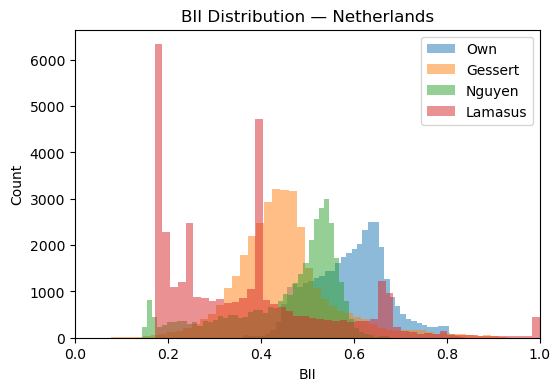

In [29]:
import numpy as np
import matplotlib.pyplot as plt

def hist_all(country, own, gess, nguy, lama):
    """
    One histogram overlay for all BII layers of a country.
    """

    # flatten + drop NaNs
    def clean(x):
        arr = x.values.flatten()
        return arr[~np.isnan(arr)]

    own_v = clean(own)
    gess_v = clean(gess)
    nguy_v = clean(nguy)
    lama_v = clean(lama)

    plt.figure(figsize=(6, 4))
    plt.hist(own_v, bins=50, alpha=0.5, label="Own", density=False)
    plt.hist(gess_v, bins=50, alpha=0.5, label="Gessert", density=False)
    plt.hist(nguy_v, bins=50, alpha=0.5, label="Nguyen", density=False)
    plt.hist(lama_v, bins=50, alpha=0.5, label="Lamasus", density=False)

    plt.title(f"BII Distribution — {country}")
    plt.xlabel("BII")
    plt.ylabel("Count")
    plt.legend()
    plt.xlim(0, 1)
    plt.show()


# 🇩🇰 Denmark
hist_all(
    "Denmark",
    bii_dnk_own_18,
    bii_gess_18_dk,
    bii_nguy_18_dk,
    bii_lama_18_dk
)

# 🇳🇱 Netherlands
hist_all(
    "Netherlands",
    bii_nld_own_18,
    bii_gess_18_nl,
    bii_nguy_18_nl,
    bii_lama_18_nl
)

In [30]:
# Denmark differences
diff_gess_dk   = bii_gess_18_dk  - bii_dnk_own_18
diff_nguy_dk   = bii_nguy_18_dk  - bii_dnk_own_18
diff_lama_dk   = bii_lama_18_dk  - bii_dnk_own_18

# Netherlands differences
diff_gess_nl   = bii_gess_18_nl  - bii_nld_own_18
diff_nguy_nl   = bii_nguy_18_nl  - bii_nld_own_18
diff_lama_nl   = bii_lama_18_nl  - bii_nld_own_18

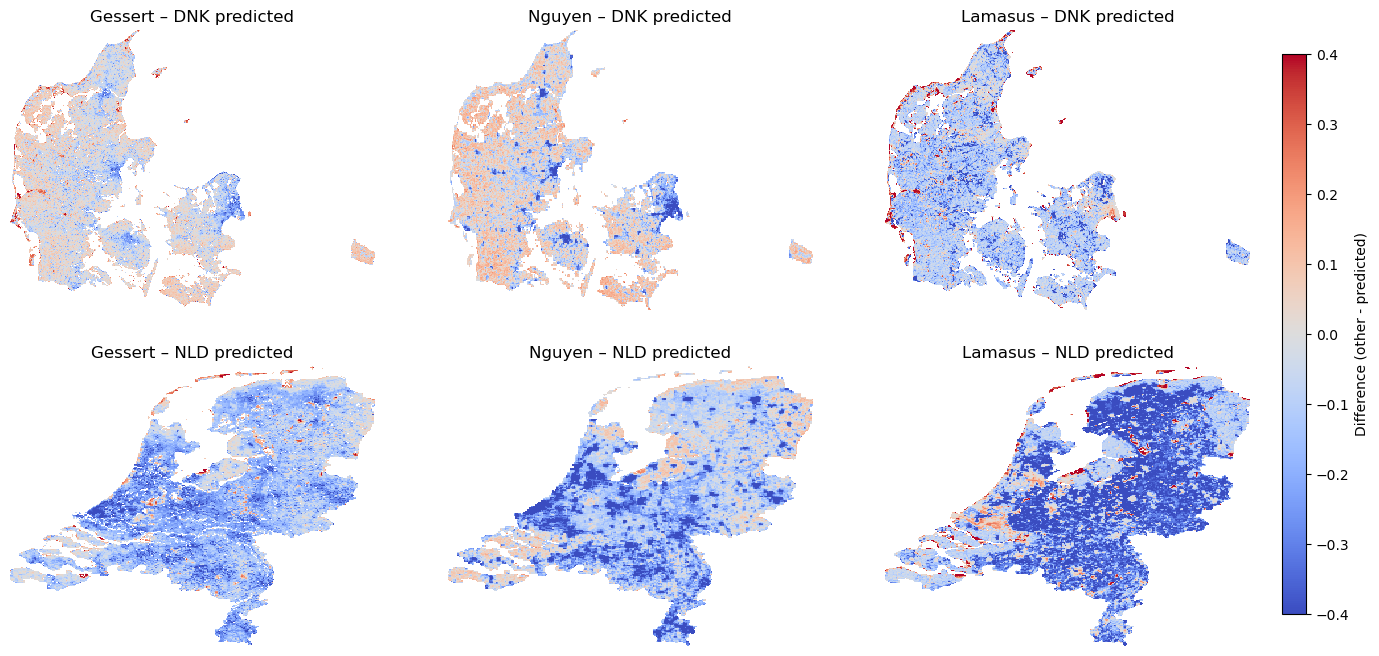

In [33]:
import matplotlib.pyplot as plt

plots = [
    ("Gessert – DNK predicted",   diff_gess_dk),
    ("Nguyen – DNK predicted", diff_nguy_dk),
    ("Lamasus – DNK predicted", diff_lama_dk),
    ("Gessert – NLD predicted",   diff_gess_nl),
    ("Nguyen – NLD predicted", diff_nguy_nl),
    ("Lamasus – NLD predicted", diff_lama_nl),
]

# Divergent colormap: negative = blue, positive = red
cmap = "coolwarm"
vmax = 0.4   # symmetric range, adjust if needed
vmin = -vmax

# Create grid: 2 rows x 3 columns
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.ravel()

for ax, (title, da) in zip(axes, plots):
    im = da.plot.imshow(ax=ax, cmap=cmap, vmin=vmin, vmax=vmax, add_colorbar=False)
    ax.set_title(title)
    ax.set_axis_off()

# Dedicated colorbar axis on right
cax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
cb = plt.colorbar(im, cax=cax)
cb.set_label("Difference (other - predicted)")

plt.subplots_adjust(right=0.9)
plt.show()

# Compare Bioscore Denmark

### Download bioscore
#### ── Direct download URL ──────────────────────────────────────────
URL = https://files-miljoegis.mim.dk/biodiversitet/biodiversitet_2021.zip
Source: https://arealdata.miljoeportal.dk/datasets/urn:dmp:ds:biodiversitetskortet-datapakke


## Data prep

In [9]:
proxy = rxr.open_rasterio(base / "Validation/Bioscore/Proxzysum_tiff.tif").squeeze()
bioscore = rxr.open_rasterio(base / "Validation/Bioscore/Bioscore_tiff.tif").squeeze()
artscore = rxr.open_rasterio(base / "Validation/Bioscore/Artscore_tiff.tif").squeeze()

bii_dnk_pred_21 = rxr.open_rasterio(base / "BII_LU_layer/BII layers/v1/bii_world_DK_21.tif").squeeze()
ab_dnk_pred_21 = rxr.open_rasterio(base / "BII_LU_layer/BII layers/v1/ab_world_DK_21.tif").squeeze()



In [12]:
from rasterio.enums import Resampling

# your predicted layers are already in EPSG:3035 at ~1km — use as target grid
target = bii_dnk_pred_21

# reproject + resample reference layers to match predicted grid (mean of pixels within each 1km cell)
proxy_1km = proxy.rio.reproject_match(target, resampling=Resampling.average)
bioscore_1km = bioscore.rio.reproject_match(target, resampling=Resampling.average)
artscore_1km = artscore.rio.reproject_match(target, resampling=Resampling.average)

# mask nodata
proxy_1km = proxy_1km.where(proxy_1km != proxy_1km.rio.nodata)
bioscore_1km = bioscore_1km.where(bioscore_1km != bioscore_1km.rio.nodata)
artscore_1km = artscore_1km.where(artscore_1km != artscore_1km.rio.nodata)

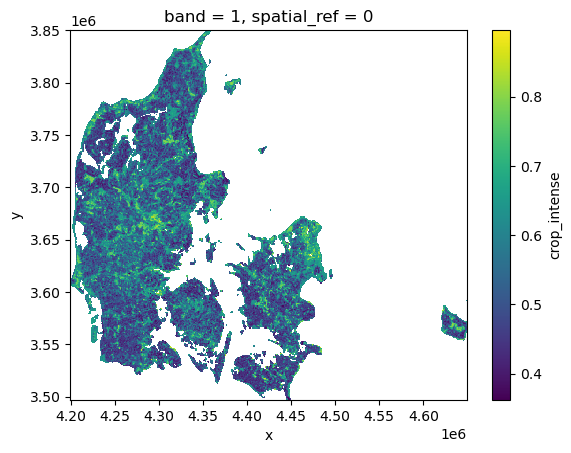

In [18]:
target.plot()

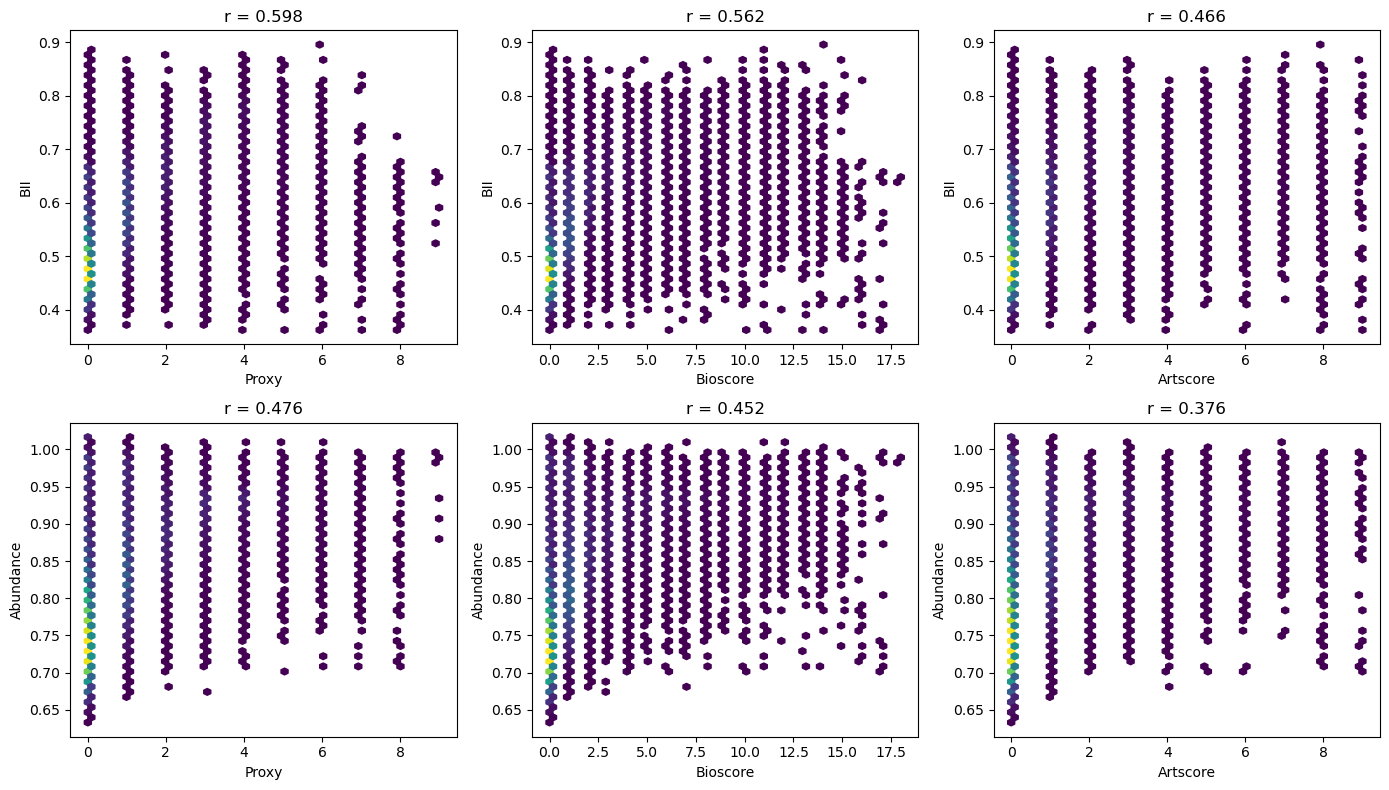

In [19]:
import matplotlib.pyplot as plt
import numpy as np

ref = {"Proxy": proxy_1km, "Bioscore": bioscore_1km, "Artscore": artscore_1km}
pred = {"BII": bii_dnk_pred_21, "Abundance": ab_dnk_pred_21}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for i, (pname, pdata) in enumerate(pred.items()):
    for j, (rname, rdata) in enumerate(ref.items()):
        ax = axes[i, j]
        mask = np.isfinite(pdata.values) & np.isfinite(rdata.values)
        x, y = rdata.values[mask], pdata.values[mask]
        ax.hexbin(x, y, gridsize=50, cmap="viridis", mincnt=1)
        r = np.corrcoef(x, y)[0, 1]
        ax.set_xlabel(rname)
        ax.set_ylabel(pname)
        ax.set_title(f"r = {r:.3f}")

plt.tight_layout()
plt.show()

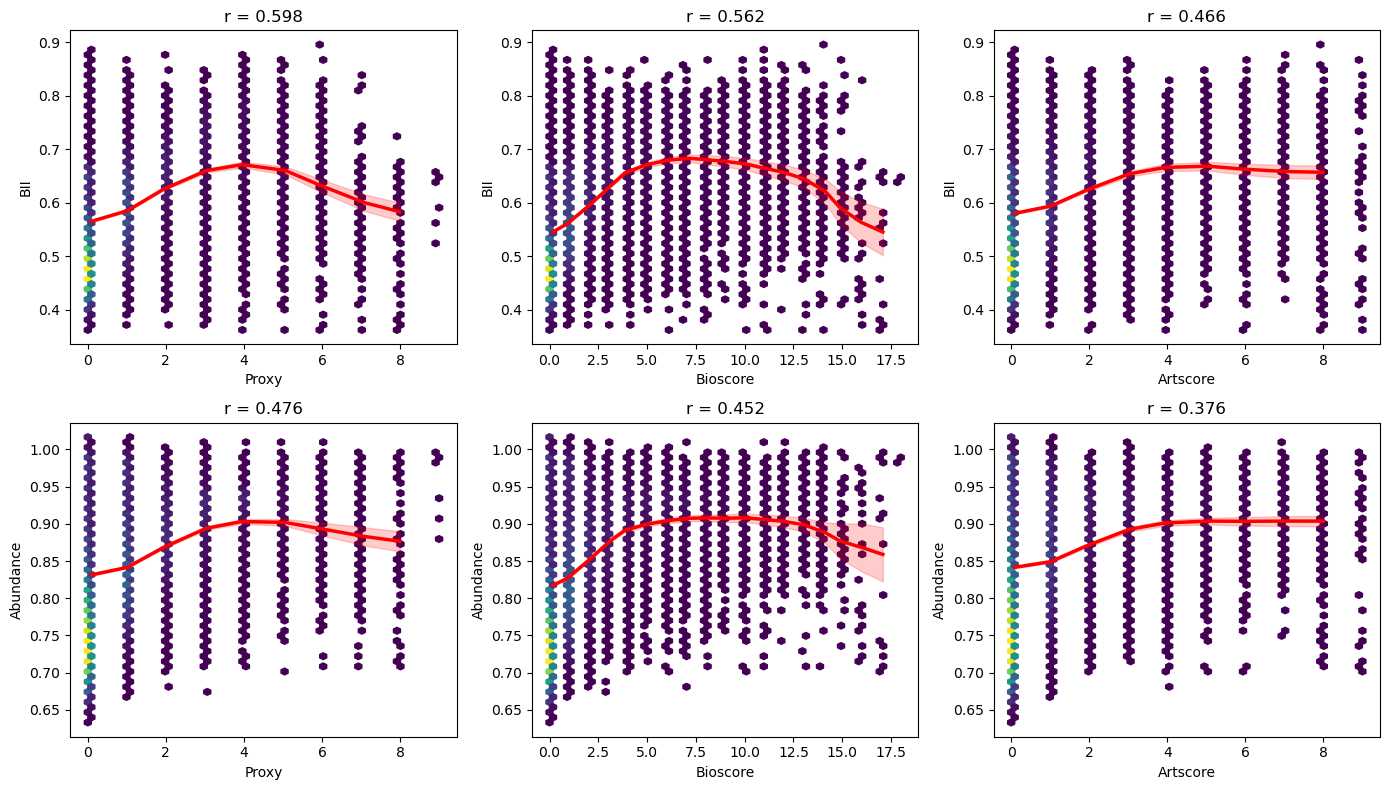

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for i, (pname, pdata) in enumerate(pred.items()):
    for j, (rname, rdata) in enumerate(ref.items()):
        ax = axes[i, j]
        mask = np.isfinite(pdata.values) & np.isfinite(rdata.values)
        x, y = rdata.values[mask], pdata.values[mask]
        ax.hexbin(x, y, gridsize=50, cmap="viridis", mincnt=1)
        # binned trend + uncertainty
        bins = np.linspace(x.min(), x.max(), 50)
        idx = np.digitize(x, bins)
        bin_centers = 0.5 * (bins[:-1] + bins[1:])
        counts = np.array([np.sum(idx == k) for k in range(1, len(bins))])
        bin_means = np.array([y[idx == k].mean() if counts[k-1] > 0 else np.nan for k in range(1, len(bins))])
        bin_std = np.array([y[idx == k].std() if counts[k-1] > 1 else np.nan for k in range(1, len(bins))])
        bin_se = bin_std / np.sqrt(counts)
        valid = np.isfinite(bin_means) & np.isfinite(bin_se)
        mu = uniform_filter1d(bin_means[valid], size=5)
        se = uniform_filter1d(bin_se[valid], size=5)
        xv = bin_centers[valid]
        ax.plot(xv, mu, "r-", lw=2.5)
        ax.fill_between(xv, mu - 1.96*se, mu + 1.96*se, color="red", alpha=0.2)
        r = np.corrcoef(x, y)[0, 1]
        ax.set_xlabel(rname)
        ax.set_ylabel(pname)
        ax.set_title(f"r = {r:.3f}")

plt.tight_layout()
plt.show()

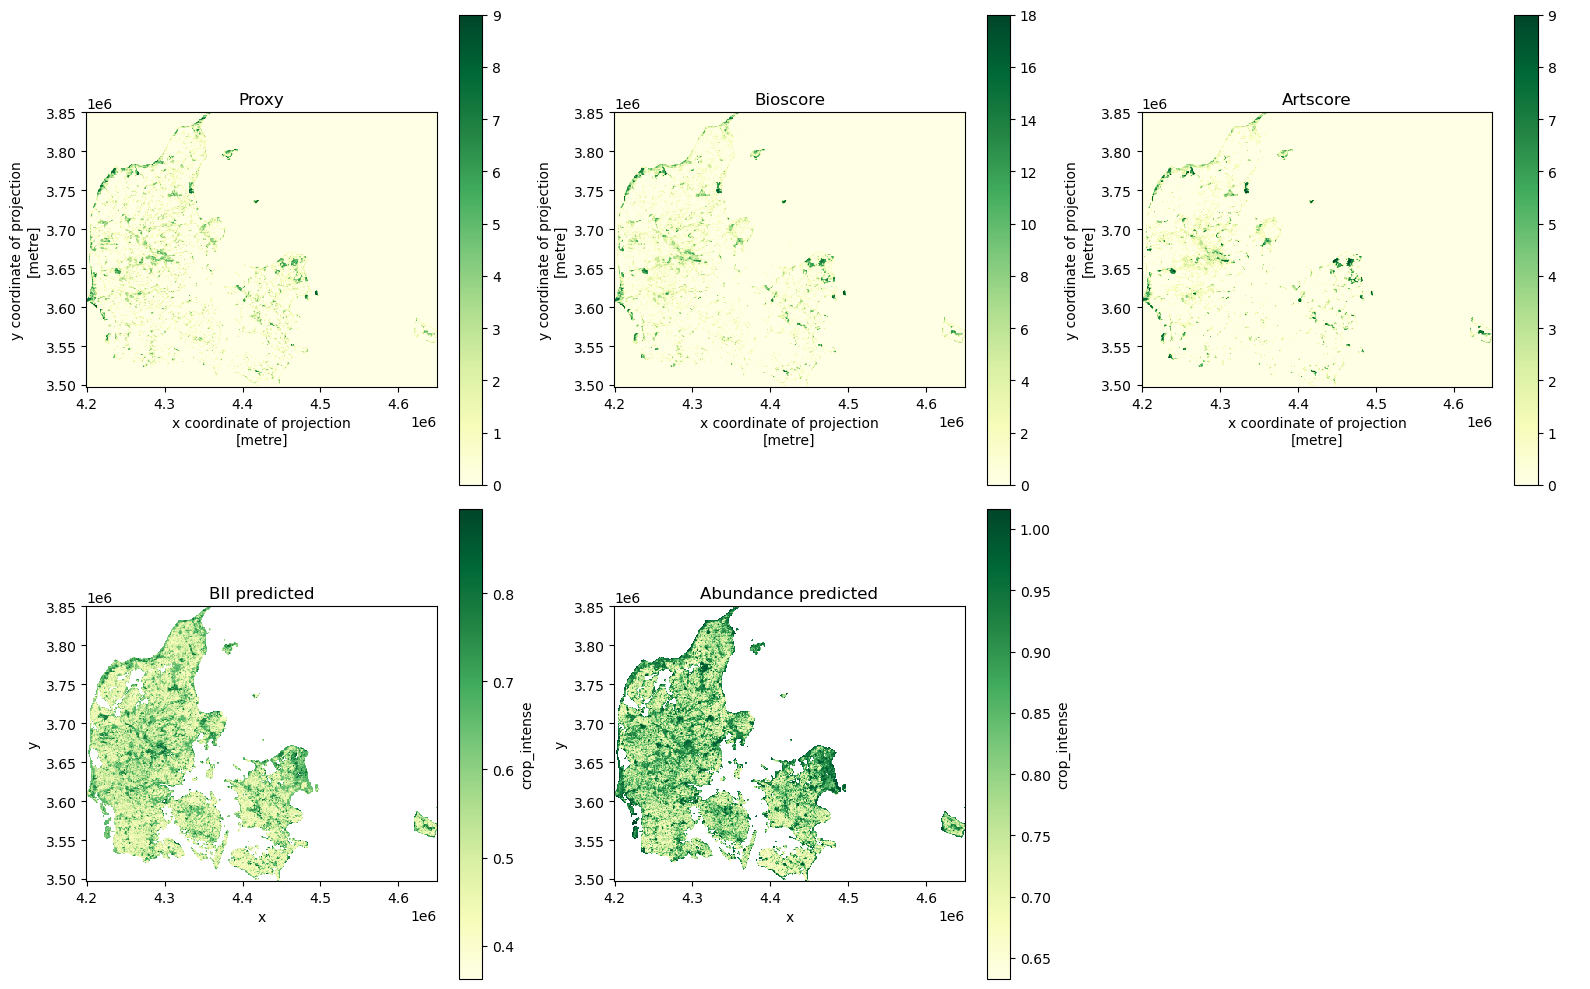

In [24]:
import matplotlib.colors as mcolors

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# top row: reference layers
for ax, (name, data) in zip(axes[0], ref.items()):
    data.plot(ax=ax, cmap="YlGn", add_colorbar=True)
    ax.set_title(name)
    ax.set_aspect("equal")

# bottom row: predicted layers + empty
bii_dnk_pred_21.plot(ax=axes[1, 0], cmap="YlGn", add_colorbar=True)
axes[1, 0].set_title("BII predicted")
axes[1, 0].set_aspect("equal")

ab_dnk_pred_21.plot(ax=axes[1, 1], cmap="YlGn", add_colorbar=True)
axes[1, 1].set_title("Abundance predicted")
axes[1, 1].set_aspect("equal")

axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

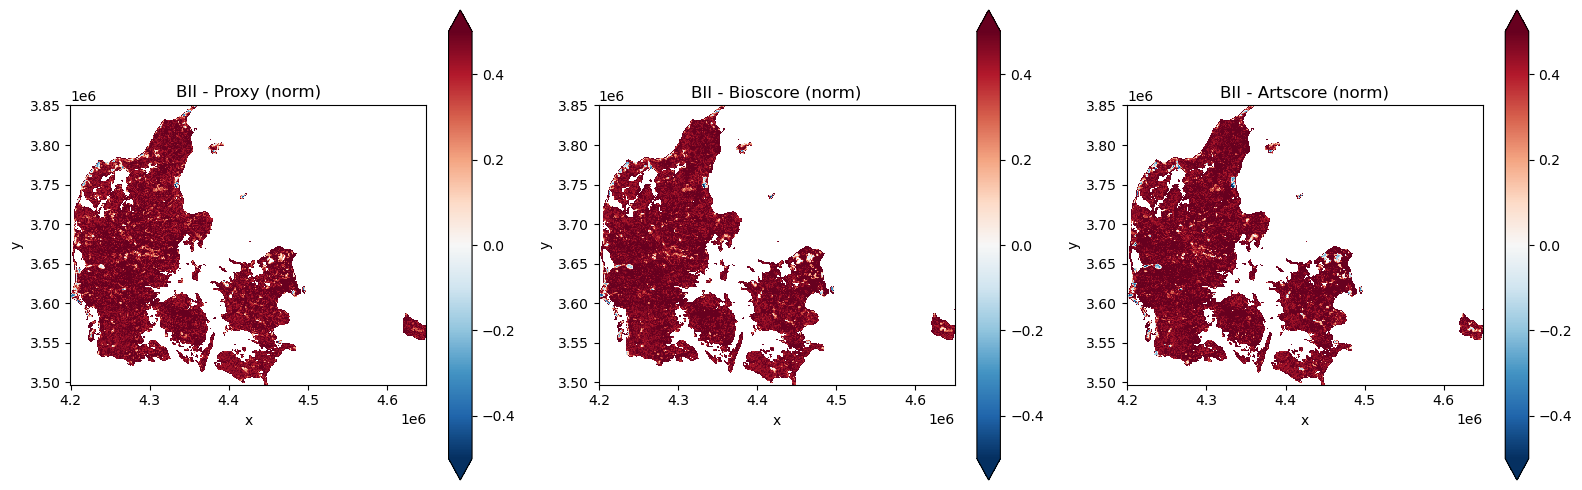

In [25]:
# normalize reference layers to 0-1 for fair comparison
def norm01(da):
    mn, mx = float(da.min()), float(da.max())
    return (da - mn) / (mx - mn)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, data) in zip(axes, ref.items()):
    diff = bii_dnk_pred_21 - norm01(data)
    diff.plot(ax=ax, cmap="RdBu_r", vmin=-0.5, vmax=0.5, add_colorbar=True)
    ax.set_title(f"BII - {name} (norm)")
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

# Gridcell network No of species

In [17]:
import geopandas as gpd
gridcell_dnk = gpd.read_file(base / "Validation/gridcell_dnk.gpkg")

bii_dnk_pred_21 = rxr.open_rasterio(base / "BII_LU_layer/BII layers/v1/bii_world_DK_21.tif").squeeze()
ab_dnk_pred_21 = rxr.open_rasterio(base / "BII_LU_layer/BII layers/v1/ab_world_DK_21.tif").squeeze()


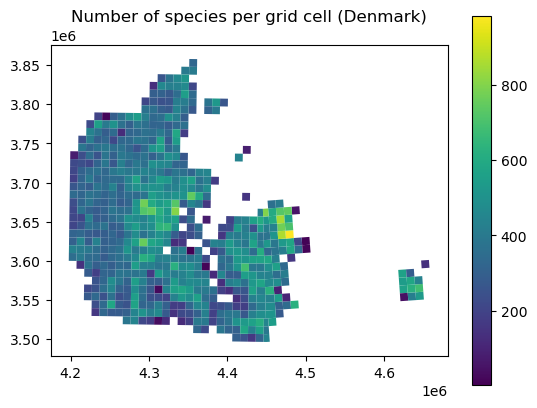

In [23]:
gridcell_dnk.plot(column="No_of_species", cmap="viridis", legend=True)
plt.title("Number of species per grid cell (Denmark)")
plt.show()

In [24]:
import geopandas as gpd
import rioxarray as rxr
from pathlib import Path

# Vector grid (has 'No_of_species')
gridcell_dnk = gpd.read_file(base / "Validation/gridcell_dnk.gpkg")

# Rasters (rioxarray)
bii_da = rxr.open_rasterio(base / "BII_LU_layer/BII layers/v1/bii_world_DK_21.tif").squeeze()
ab_da  = rxr.open_rasterio(base / "BII_LU_layer/BII layers/v1/ab_world_DK_21.tif").squeeze()
cd_da  = rxr.open_rasterio(base / "BII_LU_layer/BII layers/v1/cd_world_DK_21.tif").squeeze()


# Make sure rasters share the same CRS
assert bii_da.rio.crs == ab_da.rio.crs, "BII and AB rasters have different CRS!"
assert bii_da.rio.crs == cd_da.rio.crs, "BII and CD rasters have different CRS!"

# Reproject grid to the raster CRS (if needed)
if gridcell_dnk.crs != bii_da.rio.crs:
    gridcell_dnk = gridcell_dnk.to_crs(bii_da.rio.crs)

In [39]:
!pip install rasterstats

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [rasterstats]


In [25]:
from rasterstats import zonal_stats
import numpy as np
import pandas as pd

# Using file paths is fastest for rasterstats
bii_path = base / "BII_LU_layer/BII layers/v1/bii_world_DK_21.tif"
ab_path  = base / "BII_LU_layer/BII layers/v1/ab_world_DK_21.tif"
cd_path  = base / "BII_LU_layer/BII layers/v1/cd_world_DK_21.tif"

# Nodata values
bii_nodata = bii_da.rio.nodata
ab_nodata  = ab_da.rio.nodata
cd_nodata  = cd_da.rio.nodata

# Choose whether to include pixels that just touch polygon boundaries
ALL_TOUCHED = False  # set True if your grid cells are small/coarse and you want to include edge pixels

# Compute stats per polygon
stats_list = ["count", "mean", "median", "std", "min", "max"]

zs_bii = zonal_stats(
    gridcell_dnk, bii_path,
    stats=stats_list,
    nodata=bii_nodata,
    all_touched=ALL_TOUCHED,
    geojson_out=False
)

zs_ab = zonal_stats(
    gridcell_dnk, ab_path,
    stats=stats_list,
    nodata=ab_nodata,
    all_touched=ALL_TOUCHED,
    geojson_out=False
)

zs_cd = zonal_stats(
    gridcell_dnk, cd_path,
    stats=stats_list,
    nodata=cd_nodata,
    all_touched=ALL_TOUCHED,
    geojson_out=False
)

# Attach to GeoDataFrame
gridcell_dnk = gridcell_dnk.assign(
    bii_mean   =[d["mean"]   for d in zs_bii],
    bii_median =[d["median"] for d in zs_bii],
    bii_std    =[d["std"]    for d in zs_bii],
    ab_mean    =[d["mean"]   for d in zs_ab],
    ab_median  =[d["median"] for d in zs_ab],
    ab_std     =[d["std"]    for d in zs_ab],
    cd_mean    =[d["mean"]   for d in zs_cd],
    cd_median  =[d["median"] for d in zs_cd],
    cd_std     =[d["std"]    for d in zs_cd],
)

In [26]:
# How many valid cells?
valid = gridcell_dnk[["No_of_species", "bii_mean", "ab_mean", "cd_mean"]].dropna()
print(f"Valid rows: {len(valid)} / {len(gridcell_dnk)}")

# Check the value ranges
print(valid[["bii_mean", "ab_mean", "cd_mean"]].describe())

Valid rows: 633 / 633
         bii_mean     ab_mean     cd_mean
count  633.000000  633.000000  633.000000
mean     0.554217    0.826922    0.667616
std      0.052117    0.055689    0.029687
min      0.417065    0.705884    0.547045
25%      0.515545    0.785768    0.646929
50%      0.546958    0.817035    0.663063
75%      0.584772    0.857267    0.685683
max      0.727572    0.989577    0.767812


Pearson correlation matrix:
                No_of_species  bii_mean  ab_mean  cd_mean
No_of_species          1.000     0.253    0.022    0.474
bii_mean               0.253     1.000    0.890    0.757
ab_mean                0.022     0.890    1.000    0.378
cd_mean                0.474     0.757    0.378    1.000
Spearman correlation matrix:
                No_of_species  bii_mean  ab_mean  cd_mean
No_of_species          1.000     0.243    0.085    0.466
bii_mean               0.243     1.000    0.912    0.722
ab_mean                0.085     0.912    1.000    0.405
cd_mean                0.466     0.722    0.405    1.000


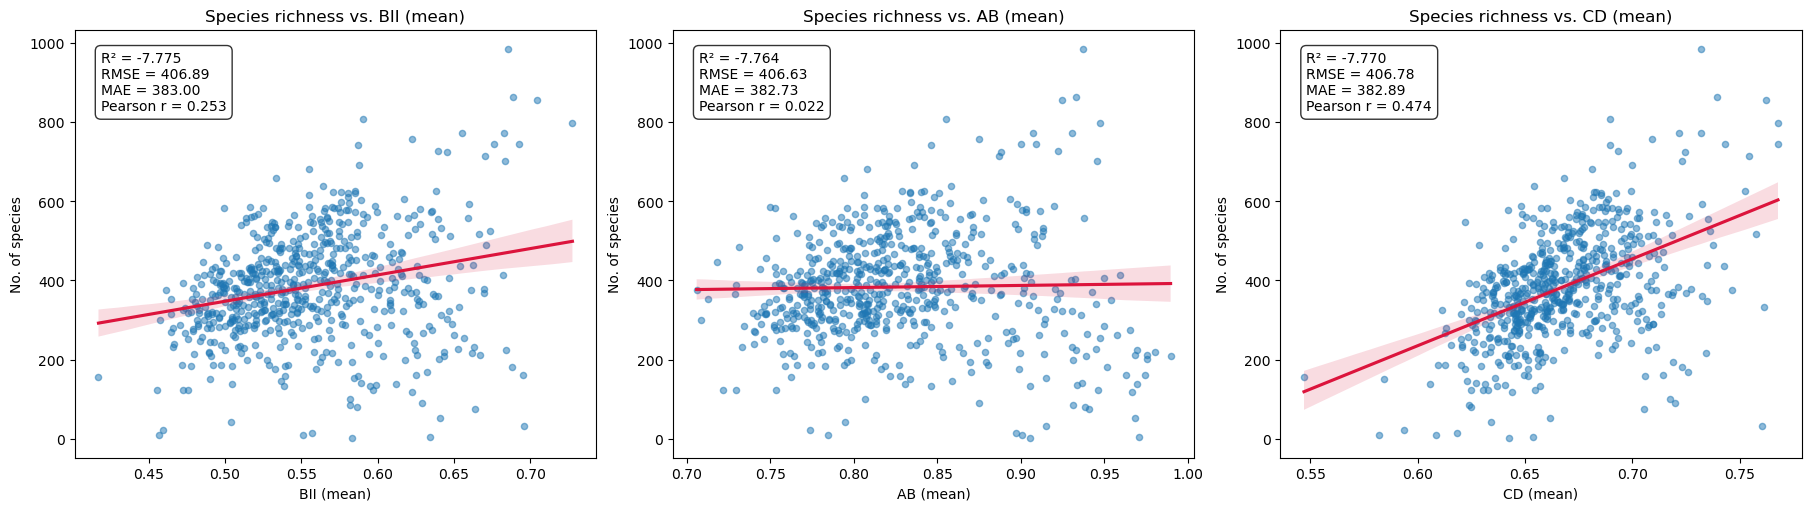

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

df = gridcell_dnk[["No_of_species", "bii_mean", "ab_mean", "cd_mean"]].dropna().copy()

# Correlations
pearson  = df.corr(method="pearson")
spearman = df.corr(method="spearman")
print("Pearson correlation matrix:\n", pearson.round(3))
print("Spearman correlation matrix:\n", spearman.round(3))

# Helper to compute and annotate stats
def annotate_stats(ax, x, y):
    r2   = r2_score(y, x)  # treating x as "predicted" of y
    rmse = np.sqrt(mean_squared_error(y, x))
    mae  = mean_absolute_error(y, x)
    r_p  = np.corrcoef(x, y)[0, 1]
    text = (f"R² = {r2:.3f}\n"
            f"RMSE = {rmse:.2f}\n"
            f"MAE = {mae:.2f}\n"
            f"Pearson r = {r_p:.3f}")
    ax.text(0.05, 0.95, text, transform=ax.transAxes,
            fontsize=10, verticalalignment="top",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.8))

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

for ax, xcol, label in zip(axes, ["bii_mean", "ab_mean", "cd_mean"],
                                  ["BII (mean)", "AB (mean)", "CD (mean)"]):
    sns.regplot(data=df, x=xcol, y="No_of_species", ax=ax,
                scatter_kws={"s": 20, "alpha": 0.5}, line_kws={"color": "crimson"})
    ax.set_title(f"Species richness vs. {label}")
    ax.set_xlabel(label)
    ax.set_ylabel("No. of species")
    annotate_stats(ax, df[xcol].values, df["No_of_species"].values)

plt.show()

Pearson correlation matrix:
                No_of_species  bii_mean  ab_mean  cd_mean
No_of_species          1.000     0.253    0.022    0.474
bii_mean               0.253     1.000    0.890    0.757
ab_mean                0.022     0.890    1.000    0.378
cd_mean                0.474     0.757    0.378    1.000
Spearman correlation matrix:
                No_of_species  bii_mean  ab_mean  cd_mean
No_of_species          1.000     0.243    0.085    0.466
bii_mean               0.243     1.000    0.912    0.722
ab_mean                0.085     0.912    1.000    0.405
cd_mean                0.466     0.722    0.405    1.000


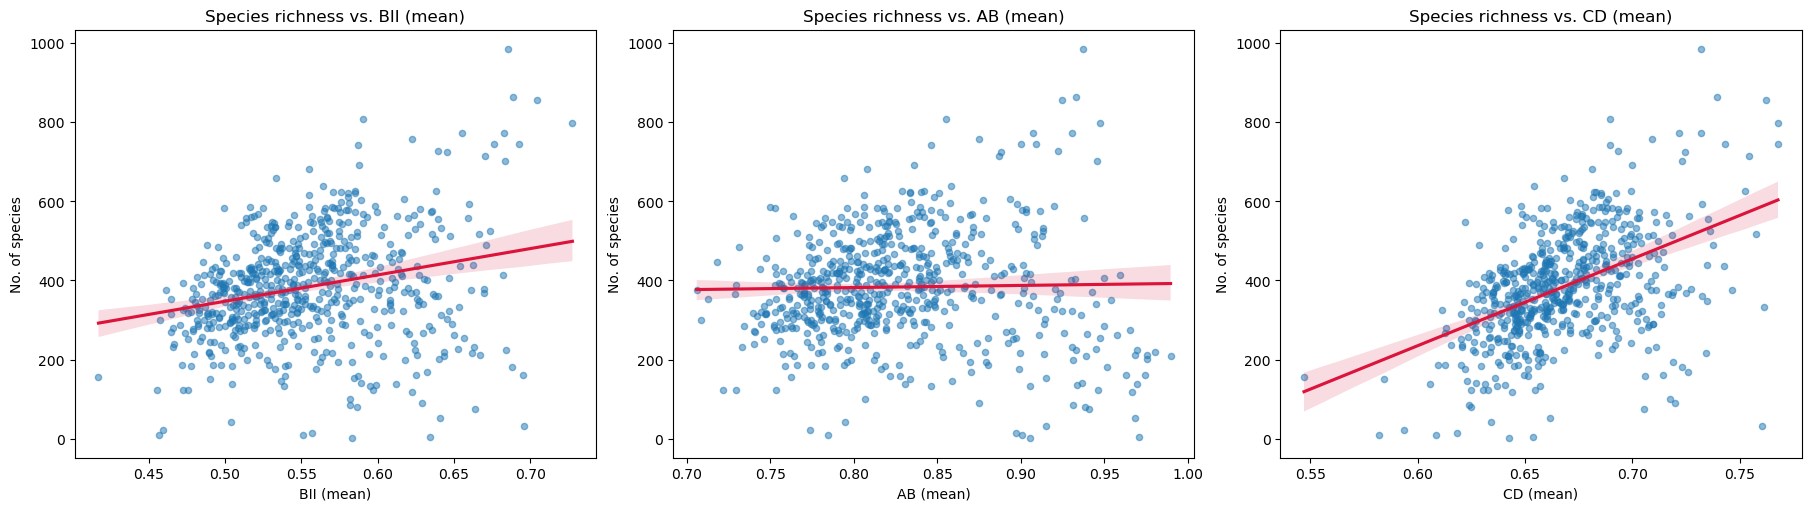

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

df = gridcell_dnk[["No_of_species", "bii_mean", "ab_mean", "cd_mean"]].dropna().copy()

# Correlations
pearson  = df.corr(method="pearson")
spearman = df.corr(method="spearman")
print("Pearson correlation matrix:\n", pearson.round(3))
print("Spearman correlation matrix:\n", spearman.round(3))

# Scatter + regression lines
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

sns.regplot(
    data=df, x="bii_mean", y="No_of_species",
    ax=axes[0], scatter_kws={"s": 20, "alpha": 0.5}, line_kws={"color":"crimson"}
)
axes[0].set_title("Species richness vs. BII (mean)")
axes[0].set_xlabel("BII (mean)")
axes[0].set_ylabel("No. of species")

sns.regplot(
    data=df, x="ab_mean", y="No_of_species",
    ax=axes[1], scatter_kws={"s": 20, "alpha": 0.5}, line_kws={"color":"crimson"}
)
axes[1].set_title("Species richness vs. AB (mean)")
axes[1].set_xlabel("AB (mean)")
axes[1].set_ylabel("No. of species")

sns.regplot(
    data=df, x="cd_mean", y="No_of_species",
    ax=axes[2], scatter_kws={"s": 20, "alpha": 0.5}, line_kws={"color":"crimson"}
)
axes[2].set_title("Species richness vs. CD (mean)")
axes[2].set_xlabel("CD (mean)")
axes[2].set_ylabel("No. of species")

plt.show()

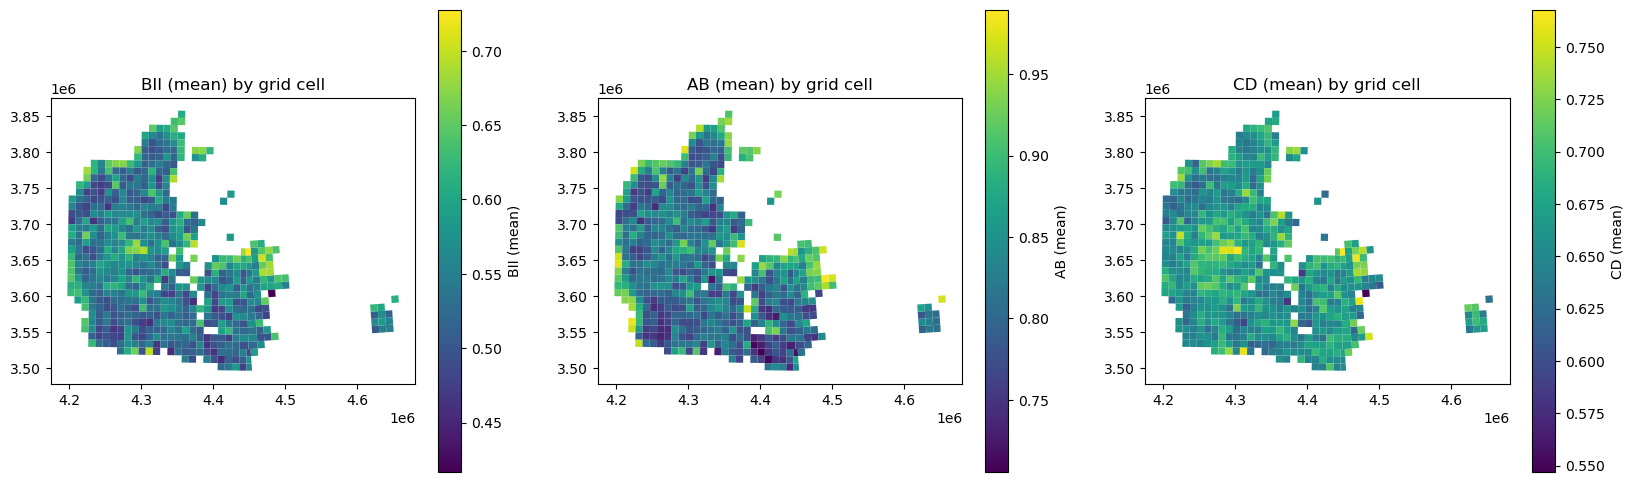

In [30]:
fig, ax = plt.subplots(1, 3, figsize=(20, 6))
gridcell_dnk.plot(column="bii_mean", cmap="viridis", legend=True,
                  legend_kwds={"label":"BII (mean)"}, ax=ax[0])
ax[0].set_title("BII (mean) by grid cell")

gridcell_dnk.plot(column="ab_mean", cmap="viridis", legend=True,
                  legend_kwds={"label":"AB (mean)"}, ax=ax[1])
ax[1].set_title("AB (mean) by grid cell")
gridcell_dnk.plot(column="cd_mean", cmap="viridis", legend=True,
                  legend_kwds={"label":"CD (mean)"}, ax=ax[2])
ax[2].set_title("CD (mean) by grid cell")
plt.show()

In [ ]:
# Save enriched grid with stats
out_gpkg = base / "Validation/gridcell_dnk_with_bii_ab.gpkg"
gridcell_dnk.to_file(out_gpkg, driver="GPKG")

# Also a flat table if you want to use it in R/Excel
gridcell_dnk.drop(columns="geometry").to_csv(base / "Validation/gridcell_dnk_bii_ab.csv", index=False)